# Ejemplo de DBSCAN con el dataset Wine

## Objetivos

En este notebook utilizaremos el dataset Wine de `scikit-learn` para:

1. cargar y explorar brevemente los datos;
2. analizar la distribución de las variables y seleccionar Pearson o Spearman para el análisis de correlación;
3. estandarizar las variables antes de calcular distancias;
4. aplicar DBSCAN;
5. estudiar los hiperparámetros `eps` y `min_samples`;
6. analizar el porcentaje de ruido y el número de clusters encontrados;
7. evaluar las particiones mediante Silhouette, Davies-Bouldin y Calinski-Harabasz;
8. visualizar e interpretar los clusters encontrados;
9. comparar al final con las clases reales del dataset como evaluación externa.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from scipy.stats import shapiro

pd.set_option("display.max_columns", None)

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

## 2. Carga del dataset

`load_wine()` contiene 178 observaciones, 13 características químicas numéricas y tres clases reales correspondientes a diferentes tipos de vino. Durante el clustering trabajaremos únicamente con $X$.

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

print("Dimensiones de X:", X.shape)
print("Número de clases reales:", y.nunique())
X.head()

Dimensiones de X: (178, 13)
Número de clases reales: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3. Exploración inicial

Antes de aplicar DBSCAN revisaremos valores faltantes, estadísticos descriptivos, diferencias de escala, distribución de las variables y correlaciones. Esto es especialmente importante porque DBSCAN depende de distancias entre observaciones.

In [3]:
print("Valores faltantes por variable:")
display(X.isna().sum().to_frame("faltantes"))

print("\nEstadísticos descriptivos:")
display(X.describe().T)

Valores faltantes por variable:


,faltantes
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0



Estadísticos descriptivos:


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### 3.1. Comparación de escalas

In [4]:
ranges = pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "rango": X.max() - X.min(),
    "media": X.mean(),
    "std": X.std()
}).sort_values("rango", ascending=False)

ranges

,min,max,rango,media,std
proline,278.00,1680.00,1402.00,746.893258,314.907474
magnesium,70.00,162.00,92.00,99.741573,14.282484
alcalinity_of_ash,10.60,30.00,19.40,19.494944,3.339564
color_intensity,1.28,13.00,11.72,5.058090,2.318286
malic_acid,0.74,5.80,5.06,2.336348,1.117146
flavanoids,0.34,5.08,4.74,2.029270,0.998859
alcohol,11.03,14.83,3.80,13.000618,0.811827
proanthocyanins,0.41,3.58,3.17,1.590899,0.572359
total_phenols,0.98,3.88,2.90,2.295112,0.625851
od280/od315_of_diluted_wines,1.27,4.00,2.73,2.611685,0.709990


Las variables tienen escalas muy diferentes. Como DBSCAN utiliza distancias, las variables con rangos mayores podrían dominar la definición de las vecindades. Por esta razón aplicaremos estandarización.

### 3.2. Distribución de las variables: decisión entre Pearson y Spearman

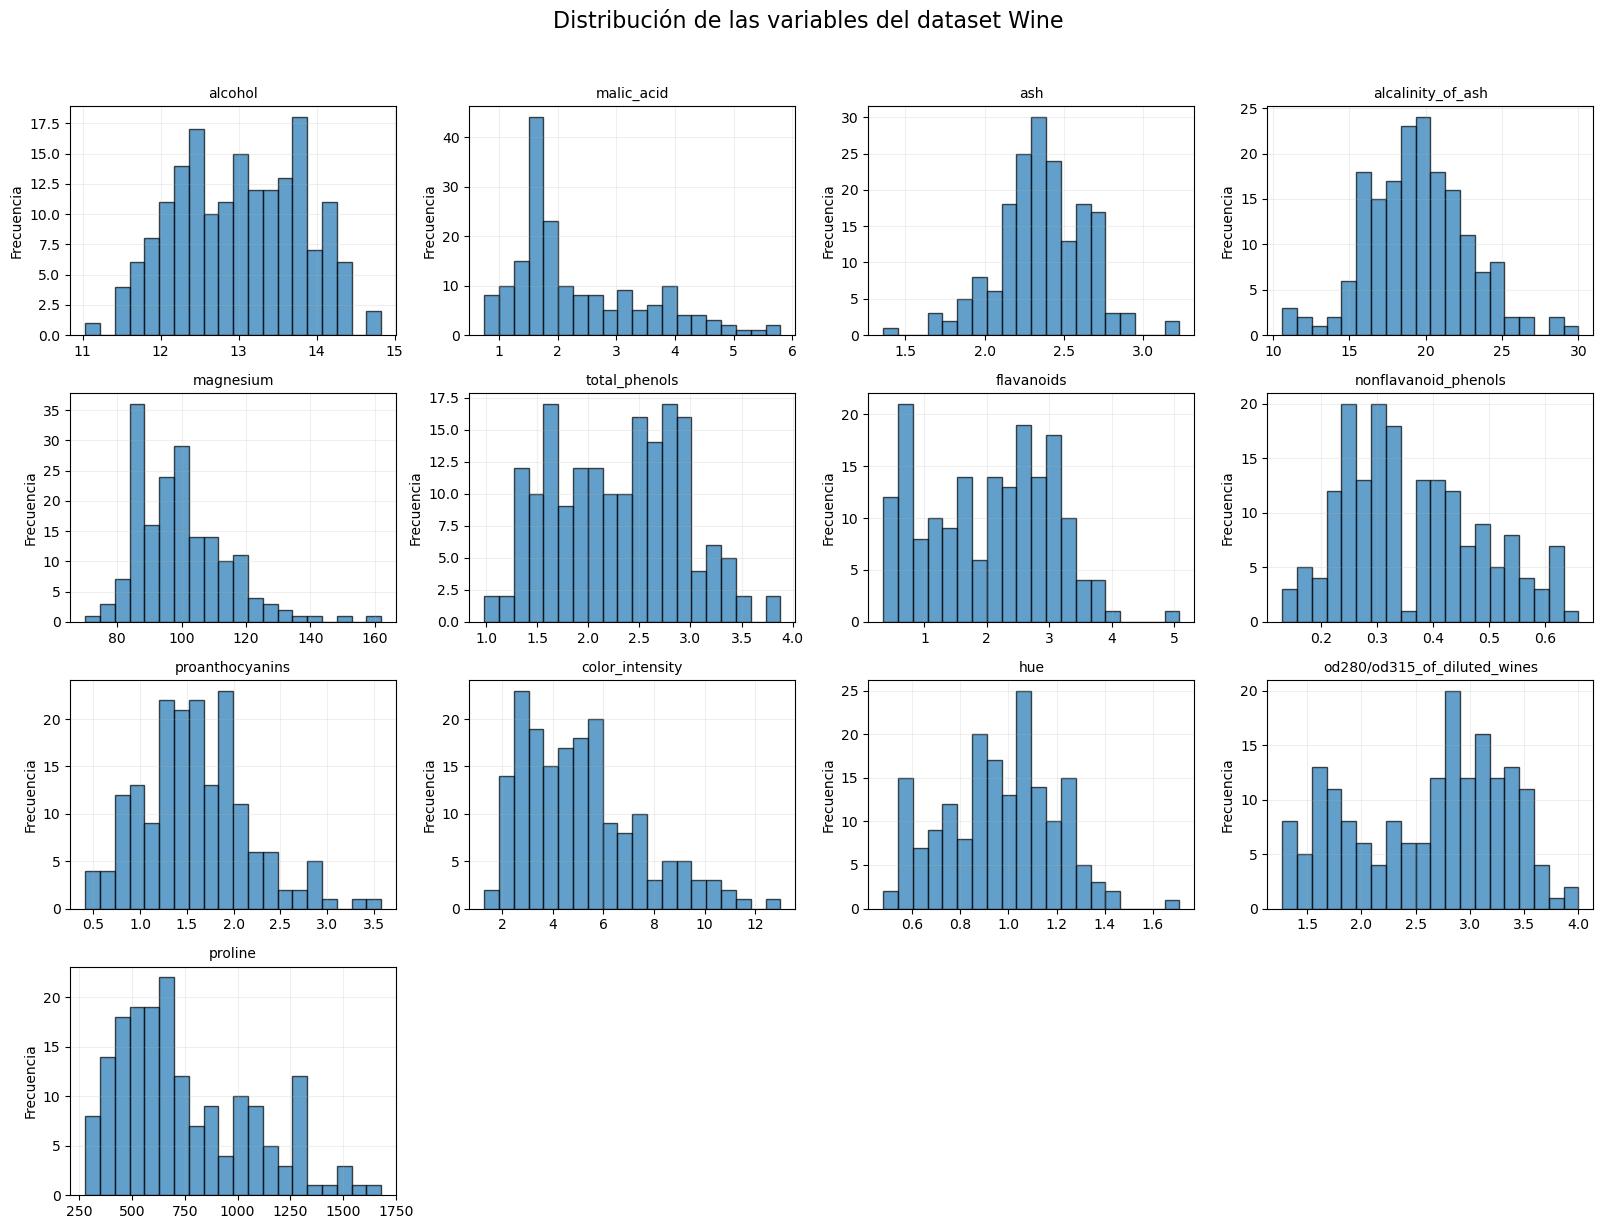

In [5]:
# Variables numéricas del dataset
features = X.columns

n_cols = 4
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(X[col], bins=20, edgecolor="black", alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(alpha=0.2)

# Ocultar subplots sobrantes
for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Distribución de las variables del dataset Wine",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [6]:
normality_rows = []

for variable in X.columns:
    stat, p_value = shapiro(X[variable])
    normality_rows.append({
        "variable": variable,
        "W": stat,
        "p_value": p_value,
        "¿No se rechaza normalidad?": p_value >= 0.05
    })

normality = pd.DataFrame(normality_rows).set_index("variable")
normality.round(4)

,W,p_value,¿No se rechaza normalidad?
variable,,,
alcohol,0.9818,0.0200,False
malic_acid,0.8888,0.0000,False
ash,0.9839,0.0387,False
alcalinity_of_ash,0.9902,0.2639,True
magnesium,0.9383,0.0000,False
total_phenols,0.9767,0.0044,False
flavanoids,0.9545,0.0000,False
nonflavanoid_phenols,0.9625,0.0001,False
proanthocyanins,0.9807,0.0145,False


Con un nivel de significancia de $\alpha=0.05$, si una variable tiene $p<0.05$ en Shapiro-Wilk se rechaza la hipótesis de normalidad. En Wine, la gran mayoría de las variables rechaza normalidad; por ello, para este análisis exploratorio se utiliza Spearman, que evalúa asociaciones monotónicas mediante rangos y es menos sensible a distribuciones no normales.

Nota metodológica: la normalidad no es un requisito para calcular el coeficiente de Pearson como medida descriptiva, pero sí es relevante para ciertas inferencias paramétricas. Aquí usamos la distribución como criterio didáctico para decidir entre ambos coeficientes.

Método de correlación seleccionado: Spearman
Variables que no rechazan normalidad: 1 de 13


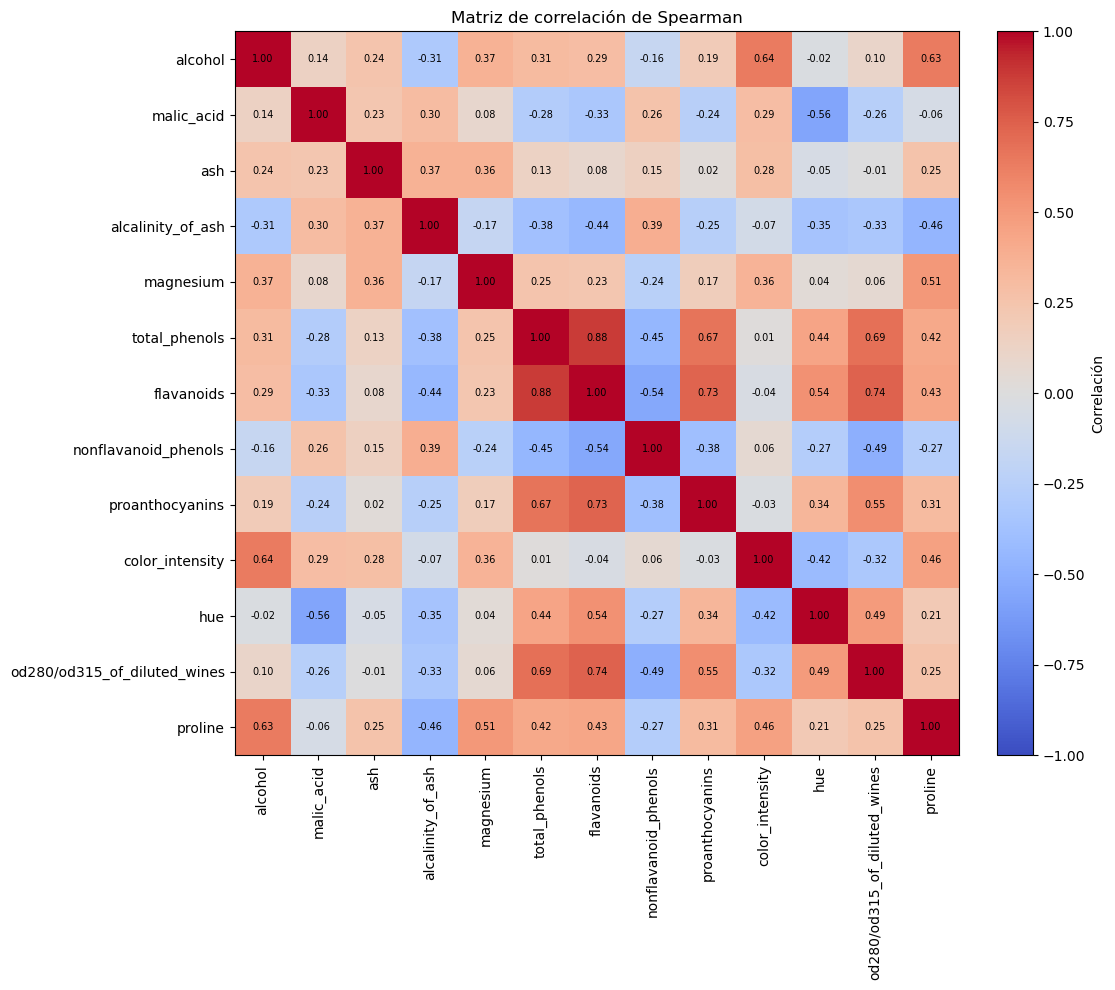

In [7]:
# Regla didáctica para este EDA:
# - Pearson si todas las variables no rechazan normalidad a alpha=0.05.
# - Spearman si al menos una variable presenta evidencia de no normalidad.
# En Wine, la gran mayoría rechaza normalidad, por lo que se utiliza Spearman.

all_normal = normality["¿No se rechaza normalidad?"].all()
corr_method = "pearson" if all_normal else "spearman"

print("Método de correlación seleccionado:", corr_method.capitalize())
print(
    "Variables que no rechazan normalidad:",
    int(normality["¿No se rechaza normalidad?"].sum()),
    "de", X.shape[1]
)

corr = X.corr(method=corr_method)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlación")
ax.set_title(f"Matriz de correlación de {corr_method.capitalize()}")
plt.tight_layout()
plt.show()

### 3.3. Pares de variables con mayor correlación absoluta

In [8]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = (
    upper.stack()
         .rename("correlacion")
         .reset_index()
         .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
strong_pairs["abs_correlacion"] = strong_pairs["correlacion"].abs()
strong_pairs = strong_pairs.sort_values("abs_correlacion", ascending=False)
strong_pairs.head(10).drop(columns="abs_correlacion").round(3)

,variable_1,variable_2,correlacion
50,total_phenols,flavanoids,0.879
61,flavanoids,od280/od315_of_diluted_wines,0.742
58,flavanoids,proanthocyanins,0.730
55,total_phenols,od280/od315_of_diluted_wines,0.687
52,total_phenols,proanthocyanins,0.667
8,alcohol,color_intensity,0.635
11,alcohol,proline,0.634
20,malic_acid,hue,-0.560
70,proanthocyanins,od280/od315_of_diluted_wines,0.554
57,flavanoids,nonflavanoid_phenols,-0.544


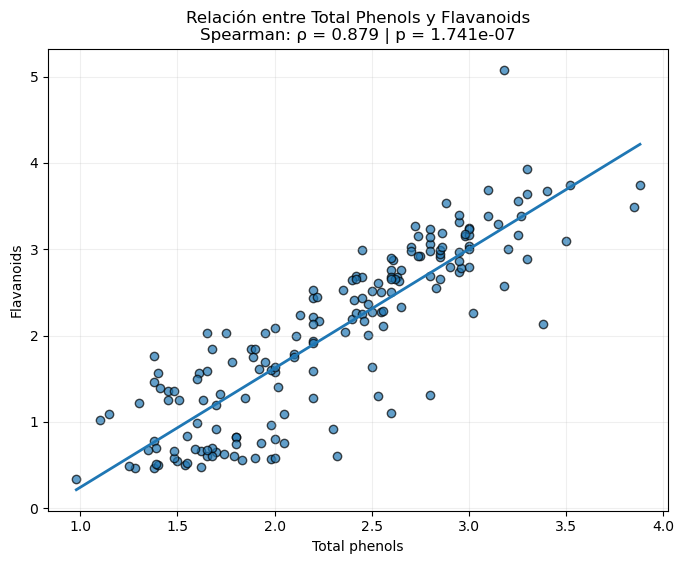

In [35]:
var1 = "total_phenols"
var2 = "flavanoids"
method = "Spearman"
symbol = "ρ"
corr_value = strong_pairs.loc[((strong_pairs["variable_1"] == var1) & (strong_pairs["variable_2"] == var2)) |
    ((strong_pairs["variable_1"] == var2) & (strong_pairs["variable_2"] == var1)), "correlacion" ].iloc[0]

plt.figure(figsize=(8, 6))

plt.scatter(X[var1], X[var2], alpha=0.7, edgecolor="black")

m, b = np.polyfit(X[var1], X[var2], 1)

x_line = np.linspace(X[var1].min(), X[var1].max(), 100)
y_line = m * x_line + b

plt.plot(x_line, y_line, linewidth=2, label="Tendencia lineal")

plt.xlabel("Total phenols")
plt.ylabel("Flavanoids")

plt.title(
    f"Relación entre Total Phenols y Flavanoids\n"
    f"{method}: {symbol} = {corr_value:.3f} | p = {p_value:.3e}"
)

plt.grid(alpha=0.2)
plt.show()

## 4. Preprocesamiento

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
alcohol,7.943708e-15,1.002821,-2.434235,2.259772
malic_acid,3.592632e-16,1.002821,-1.432983,3.109192
ash,-4.066660e-15,1.002821,-3.679162,3.156325
alcalinity_of_ash,-7.983626e-17,1.002821,-2.671018,3.154511
magnesium,-7.983626e-17,1.002821,-2.088255,4.371372
total_phenols,-3.991813e-17,1.002821,-2.107246,2.539515
flavanoids,9.979533e-16,1.002821,-1.695971,3.062832
nonflavanoid_phenols,-5.588538e-16,1.002821,-1.868234,2.402403
proanthocyanins,-1.656602e-15,1.002821,-2.069034,3.485073
color_intensity,-3.442939e-16,1.002821,-1.634288,3.435432


Después de `StandardScaler`, cada variable queda aproximadamente centrada en 0 y con desviación estándar cercana a 1.

## 5. DBSCAN

DBSCAN define grupos como regiones de alta densidad. Para cada observación considera un vecindario de radio $\varepsilon$ (`eps`) y exige un número mínimo de observaciones (`min_samples`) para identificar zonas densas.

Los puntos pueden clasificarse como core, border o noise. A diferencia de K-Means, DBSCAN no requiere especificar previamente el número de clusters.

## 7. Exploración de `eps` y `min_samples`

Como DBSCAN puede marcar observaciones como ruido (`label = -1`), las métricas internas se calcularán solo sobre las observaciones no clasificadas como ruido. También se reporta el porcentaje de ruido, porque una Silhouette alta obtenida dejando fuera demasiados puntos no necesariamente representa una solución útil.

In [11]:
def dbscan_internal_metrics(X_array, labels):
    mask = labels != -1
    valid_labels = labels[mask]
    n_clusters = len(np.unique(valid_labels))
    noise_fraction = 1 - mask.mean()

    result = {
        "n_clusters": n_clusters,
        "ruido_%": 100 * noise_fraction,
        "Silhouette ↑": np.nan,
        "Davies-Bouldin ↓": np.nan,
        "Calinski-Harabasz ↑": np.nan,
    }

    if n_clusters >= 2 and mask.sum() > n_clusters:
        result["Silhouette ↑"] = silhouette_score(X_array[mask], valid_labels)
        result["Davies-Bouldin ↓"] = davies_bouldin_score(X_array[mask], valid_labels)
        result["Calinski-Harabasz ↑"] = calinski_harabasz_score(X_array[mask], valid_labels)

    return result

results = []

for min_samples in [3, 4, 5, 6, 8, 10]:
    for eps in np.arange(1.5, 3.01, 0.1):
        labels = DBSCAN(eps=float(eps), min_samples=min_samples).fit_predict(X_scaled)
        row = {"eps": round(float(eps), 2), "min_samples": min_samples}
        row.update(dbscan_internal_metrics(X_scaled, labels))
        results.append(row)

results = pd.DataFrame(results)
results.round(3)

,eps,min_samples,n_clusters,ruido_%,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,1.5,3,8,82.584,0.331,0.919,25.273
1,1.6,3,10,69.663,0.255,1.068,23.709
2,1.7,3,10,61.236,0.234,1.191,25.231
3,1.8,3,8,50.562,0.312,1.205,32.864
4,1.9,3,9,42.135,0.290,1.315,33.240
...,...,...,...,...,...,...,...
91,2.6,10,2,15.169,0.308,1.245,71.516
92,2.7,10,1,12.360,NaN,NaN,NaN
93,2.8,10,1,10.674,NaN,NaN,NaN
94,2.9,10,1,7.865,NaN,NaN,NaN


### 7.1. Comparación de configuraciones

Filtraremos configuraciones con al menos dos clusters y no más de 40% de ruido. Este umbral no es una regla universal: se utiliza aquí para evitar seleccionar una solución aparentemente buena que simplemente descarte la mayoría de observaciones.

In [23]:
valid_results = results[
    (results["n_clusters"] > 2) &
    (results["ruido_%"] <= 40) &
    results["Silhouette ↑"].notna()
].copy()

valid_results.sort_values("Silhouette ↑", ascending=False).head(15).round(3)

,eps,min_samples,n_clusters,ruido_%,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
54,2.1,6,3,39.326,0.233,1.625,30.641
8,2.3,3,3,17.978,0.225,1.145,38.274
38,2.1,5,3,34.831,0.222,1.729,34.779
21,2.0,4,6,37.079,0.221,1.479,16.436
5,2.0,3,5,35.955,0.211,1.344,20.056
22,2.1,4,3,32.022,0.211,1.857,35.874
7,2.2,3,3,24.719,0.073,1.727,36.581
6,2.1,3,4,29.213,0.009,2.090,25.305


In [26]:
ranking = valid_results.copy()

# Ranking por métrica
# Mayor es mejor
ranking["Rank_Silhouette"] = ranking["Silhouette ↑"].rank(
    ascending=False,
    method="min"
)

ranking["Rank_CH"] = ranking["Calinski-Harabasz ↑"].rank(
    ascending=False,
    method="min"
)

# Menor es mejor
ranking["Rank_DB"] = ranking["Davies-Bouldin ↓"].rank(
    ascending=True,
    method="min"
)

ranking["Rank_Ruido"] = ranking["ruido_%"].rank(
    ascending=True,
    method="min"
)

# Ranking global: menor suma = mejor configuración
ranking["Rank_Total"] = (
    ranking["Rank_Silhouette"]
    + ranking["Rank_DB"]
    + ranking["Rank_CH"]
    + ranking["Rank_Ruido"]
)

# Ordenar de mejor a peor
ranking = ranking.sort_values(
    "Rank_Total",
    ascending=True
)

ranking.round(3)

,eps,min_samples,n_clusters,ruido_%,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑,Rank_Silhouette,Rank_CH,Rank_DB,Rank_Ruido,Rank_Total
8,2.3,3,3,17.978,0.225,1.145,38.274,2.0,1.0,1.0,1.0,5.0
7,2.2,3,3,24.719,0.073,1.727,36.581,7.0,2.0,5.0,2.0,16.0
38,2.1,5,3,34.831,0.222,1.729,34.779,3.0,4.0,6.0,5.0,18.0
54,2.1,6,3,39.326,0.233,1.625,30.641,1.0,5.0,4.0,8.0,18.0
22,2.1,4,3,32.022,0.211,1.857,35.874,6.0,3.0,7.0,4.0,20.0
5,2.0,3,5,35.955,0.211,1.344,20.056,5.0,7.0,2.0,6.0,20.0
21,2.0,4,6,37.079,0.221,1.479,16.436,4.0,8.0,3.0,7.0,22.0
6,2.1,3,4,29.213,0.009,2.090,25.305,8.0,6.0,8.0,3.0,25.0


### 7.2. Métricas frente a `eps`

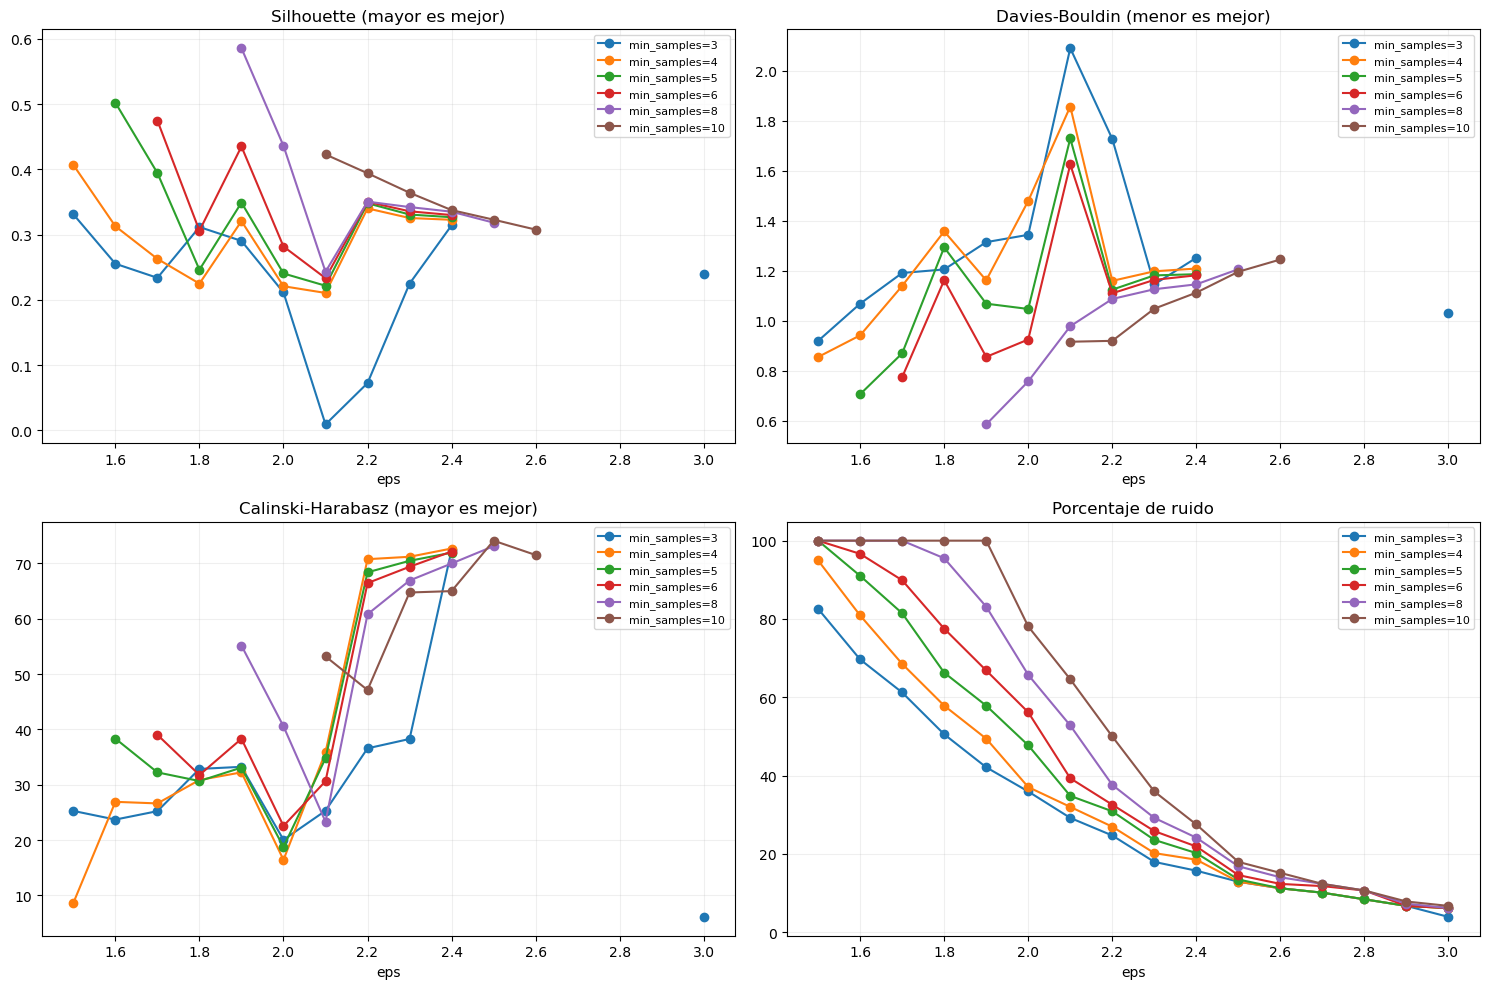

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for min_samples in [3, 4, 5, 6, 8, 10]:
    subset = results[results["min_samples"] == min_samples]
    axes[0, 0].plot(subset["eps"], subset["Silhouette ↑"], marker="o", label=f"min_samples={min_samples}")
    axes[0, 1].plot(subset["eps"], subset["Davies-Bouldin ↓"], marker="o", label=f"min_samples={min_samples}")
    axes[1, 0].plot(subset["eps"], subset["Calinski-Harabasz ↑"], marker="o", label=f"min_samples={min_samples}")
    axes[1, 1].plot(subset["eps"], subset["ruido_%"], marker="o", label=f"min_samples={min_samples}")

axes[0, 0].set_title("Silhouette (mayor es mejor)")
axes[0, 1].set_title("Davies-Bouldin (menor es mejor)")
axes[1, 0].set_title("Calinski-Harabasz (mayor es mejor)")
axes[1, 1].set_title("Porcentaje de ruido")

for ax in axes.ravel():
    ax.set_xlabel("eps")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Las configuraciones con eps bajos muestran métricas internas favorables, pero generan porcentajes elevados de ruido. A partir de eps≈2.2, el porcentaje de ruido disminuye considerablemente y las métricas tienden a estabilizarse. La región entre eps≈2.3 y 2.5, con valores moderados de min_samples, ofrece un mejor equilibrio entre calidad interna y cobertura de las observaciones.

## 8. Selección de una configuración para interpretar

In [28]:
# Seleccionamos la mejor configuración según el ranking multicriterio
best_row = ranking.iloc[0]

selected_eps = float(best_row["eps"])
selected_min_samples = int(best_row["min_samples"])

# Entrenar DBSCAN con la configuración seleccionada
selected_model = DBSCAN(
    eps=selected_eps,
    min_samples=selected_min_samples
)

selected_labels = selected_model.fit_predict(X_scaled)

# Resumen de la configuración seleccionada
n_clusters = len(set(selected_labels)) - (1 if -1 in selected_labels else 0)
noise_pct = 100 * np.mean(selected_labels == -1)

print("Configuración seleccionada según ranking multicriterio")
print("eps seleccionado:", selected_eps)
print("min_samples seleccionado:", selected_min_samples)
print("Número de clusters:", n_clusters)
print("Ruido (%):", round(noise_pct, 2))

print("\nDistribución de etiquetas:")
print(pd.Series(selected_labels).value_counts().sort_index())

Configuración seleccionada según ranking multicriterio
eps seleccionado: 2.3
min_samples seleccionado: 3
Número de clusters: 3
Ruido (%): 17.98

Distribución de etiquetas:
-1     32
 0    100
 1      3
 2     43
Name: count, dtype: int64


**Importante:** esta selección no pretende demostrar que existe un único `eps` correcto. En DBSCAN debe analizarse conjuntamente la calidad interna, el porcentaje de ruido, la estabilidad y el significado de los grupos.

## 9. Visualización de la partición con PCA

El clustering se realiza utilizando las 13 variables estandarizadas. PCA se utiliza únicamente para proyectar las observaciones a dos dimensiones y visualizar la partición.

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(
    "Varianza explicada por PC1 + PC2:",
    round(pca.explained_variance_ratio_.sum(), 3)
)

Varianza explicada por PC1 + PC2: 0.554


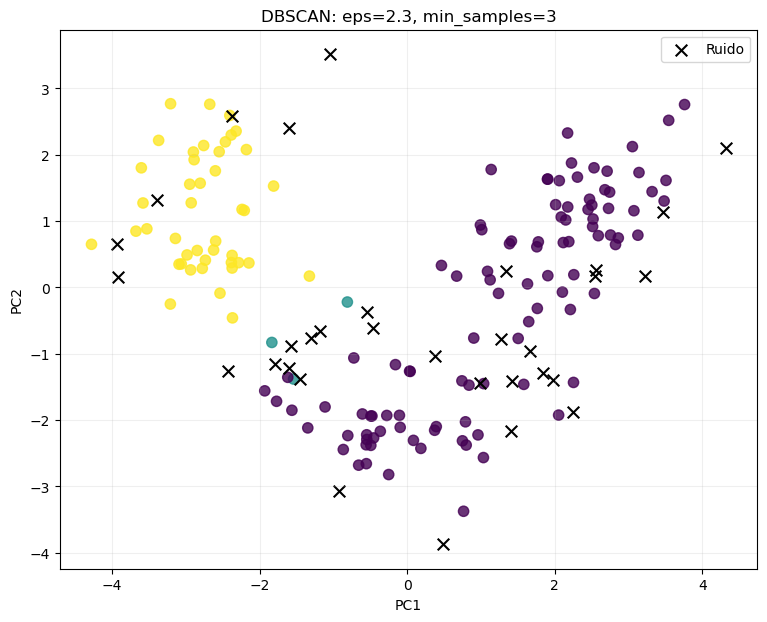

In [30]:
plt.figure(figsize=(9, 7))

noise_mask = selected_labels == -1
cluster_mask = ~noise_mask

plt.scatter(
    X_pca[cluster_mask, 0], X_pca[cluster_mask, 1],
    c=selected_labels[cluster_mask], s=55, alpha=0.8
)
plt.scatter(
    X_pca[noise_mask, 0], X_pca[noise_mask, 1],
    c="black", marker="x", s=70, label="Ruido"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"DBSCAN: eps={selected_eps}, min_samples={selected_min_samples}")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

## 10. Interpretación de los clusters

In [31]:
X_with_cluster = X.copy()
X_with_cluster["cluster"] = selected_labels

# Perfiles de clusters; se excluye el ruido para describir los grupos.
cluster_profiles = (
    X_with_cluster[X_with_cluster["cluster"] != -1]
    .groupby("cluster")
    .mean()
)
cluster_profiles

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,13.072100,1.853000,2.35590,18.559000,98.910000,2.555300,2.568900,0.318000,1.715300,4.380400,1.057600,3.040100,833.140000
1,12.770000,1.133333,2.22000,16.600000,103.666667,2.200000,1.266667,0.570000,0.483333,4.063333,1.083333,1.730000,626.666667
2,13.162326,3.317907,2.40186,21.046512,99.325581,1.622791,0.792558,0.441395,1.112791,7.214419,0.687442,1.685349,621.511628


### 10.1. Perfiles estandarizados

In [32]:
scaled_profiles = (
    pd.DataFrame(X_scaled, columns=X.columns)
    .assign(cluster=selected_labels)
    .query("cluster != -1")
    .groupby("cluster")
    .mean()
)
scaled_profiles.T

cluster,0,1,2
alcohol,0.088299,-0.284874,0.199752
malic_acid,-0.433884,-1.079902,0.881109
ash,-0.038808,-0.535569,0.129193
alcalinity_of_ash,-0.281050,-0.869308,0.465913
magnesium,-0.058388,0.275594,-0.029208
total_phenols,0.416907,-0.152402,-1.077282
flavanoids,0.541771,-0.765628,-1.241617
nonflavanoid_phenols,-0.353366,1.677201,0.640929
proanthocyanins,0.217961,-1.940548,-0.837686
color_intensity,-0.293148,-0.430302,0.932763


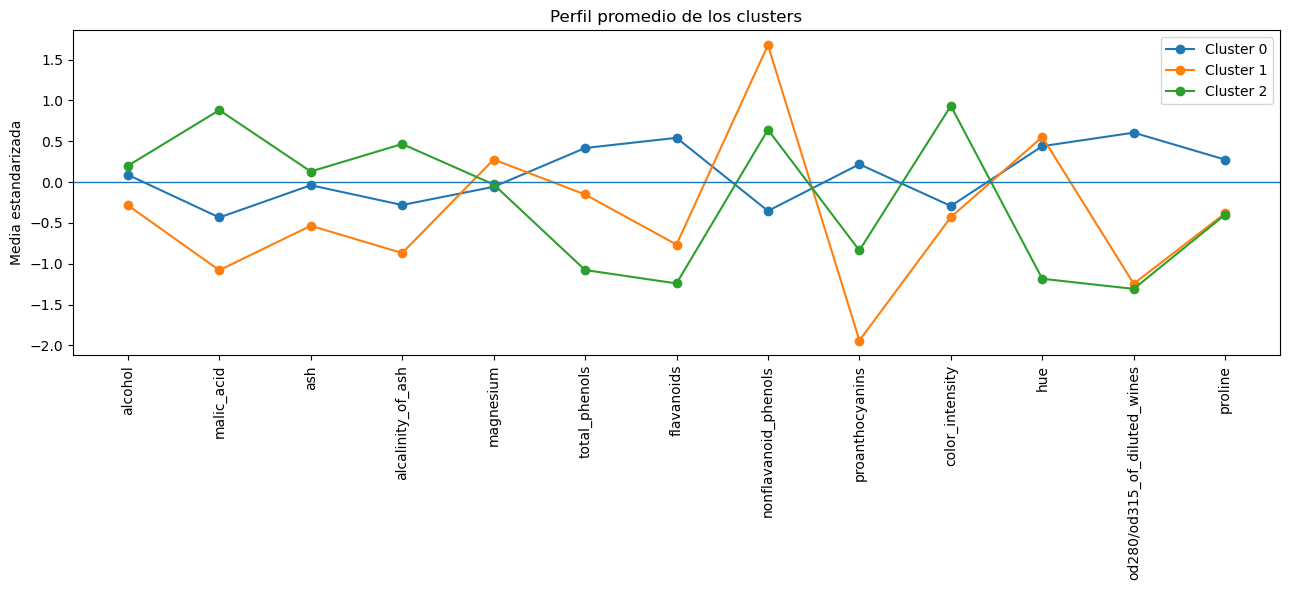

In [33]:
plt.figure(figsize=(13, 6))
for cluster_id in scaled_profiles.index:
    plt.plot(
        scaled_profiles.columns,
        scaled_profiles.loc[cluster_id],
        marker="o",
        label=f"Cluster {cluster_id}"
    )
plt.axhline(0, linewidth=1)
plt.xticks(rotation=90)
plt.ylabel("Media estandarizada")
plt.title("Perfil promedio de los clusters")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Comparación externa con las clases reales

Hasta este punto las clases reales no han participado en el clustering. Ahora se utilizan únicamente como referencia externa mediante ARI y NMI. En DBSCAN, la etiqueta `-1` de ruido se conserva como una categoría adicional en esta comparación.

In [34]:
external_metrics = pd.DataFrame({
    "ARI ↑": [adjusted_rand_score(y, selected_labels)],
    "NMI ↑": [normalized_mutual_info_score(y, selected_labels)]
}, index=["DBSCAN"])
external_metrics.round(3)

,ARI ↑,NMI ↑
DBSCAN,0.399,0.502


## 12. Lectura final

DBSCAN es especialmente útil cuando los grupos corresponden a regiones densas separadas por zonas de baja densidad y cuando interesa detectar ruido. El dataset Wine estandarizado es también un buen ejemplo para discutir sus limitaciones: en espacios de 13 dimensiones la noción de densidad puede ser menos clara y la elección de `eps` puede ser sensible.